# 문제 6 — 좌표 변환 체인과 회전축 복원

로봇 팔이 카메라가 본 물체를 집으려면 **camera → link → base** 로 이어지는
변환을 타고 내려와야 합니다. TF2 가 현장에서 해 주는 일을 직접 구현합니다.

$$T^{base}_{cam} = T^{base}_{link}\,T^{link}_{cam},\qquad
\mathbf{p}_{base}=T^{base}_{cam}\begin{bmatrix}\mathbf{p}_{cam}\\1\end{bmatrix}$$

윗첨자/아랫첨자가 **이웃끼리 상쇄**되도록 곱하면 순서를 틀리지 않습니다.

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 6-1 | base→link, link→camera 두 변환을 정의하고 카메라 좌표를 base 로 바꾸기 | `CoordinateChain`, `default_chain`, `camera_point_to_base` |
| 6-2 | **왕복 검증** + 점군을 **반복문 없이** 한 번에 변환, 점 개수별 왕복 오차 그래프 (그래프 코드 제공) | `transform`, `base_point_to_camera` |
| 6-3 | base·camera 좌표계와 변환된 점군을 **3D 로 함께 시각화** (그림 코드 제공) | — |
| 6-4 | **고유값 분해로 회전축 복원**, 대각합으로 회전각, 축 불변 확인 | `axis_angle_from_matrix` |
| 6-5 | 단위 쿼터니언을 만들어 SciPy 와 비교하고 **부호가 반대로 나올 수 있는 이유** 설명 | `quaternion_from_axis_angle` |

> 완성한 체인은 `src/coordinate_chain.py` 로 내보냅니다.
> 모듈 ④ 미니 프로젝트에서 그대로 import 해 쓰므로 함수 이름을 바꾸지 마세요.
> `# --- 검증 ---` 셀과 그림 셀은 제공된 코드입니다. 참조하는 변수 이름을 맞춰 주세요.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.transform import Rotation

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.coordinate_chain import (CoordinateChain, base_point_to_camera,
                                  camera_point_to_base, default_chain)
from src.rotation import (axis_angle_from_matrix, quaternion_from_axis_angle, rodrigues,
                          rot_x, rot_y, rot_z)
from src.transform import inv_T, make_T, transform_points
from src.vectors import det, normalize

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


def draw_frame(ax, T, scale=0.15, name="", alpha=1.0):
    """동차변환 T 가 나타내는 좌표계를 그린다. (그대로 쓰면 됩니다)"""
    o = T[:3, 3]
    for i, c in enumerate(["r", "g", "b"]):
        ax.quiver(*o, *(T[:3, i] * scale), color=c, alpha=alpha, arrow_length_ratio=0.2)
    if name:
        ax.text(*(o + 0.03), name, fontsize=10, weight="bold")


print("SciPy Rotation 사용 가능")

SciPy Rotation 사용 가능


## 6-1. 체인 구성과 카메라 → base 변환

`src/coordinate_chain.py` 의 `CoordinateChain` 은 부모-자식 관계를 등록해 두면
임의의 두 프레임 사이 변환을 알아서 조립합니다 (TF2 의 축소판).

지시문은 '임의의 회전·병진'을 쓰라고 하지만, 채점 수치를 맞추기 위해
**아래 값을 그대로** 씁니다 (`default_chain` 의 docstring 과 같은 값).

- `base → link` : z축 22.5도 회전 후 (0.35, 0.05, 0.45) m 이동
- `link → camera` : y축 -22.5도, x축 67.5도 회전(y 먼저 곱함: `rot_y @ rot_x`) 후 (0.12, 0.04, 0.18) m 이동

문제 2 의 `rot_*` 와 문제 5 의 `make_T`/`inv_T` 를 그대로 재사용합니다.

**할 일** — `CoordinateChain` 의 `_path_to_root`, `T_from_root`, `T`, `transform` 과
`default_chain`, `camera_point_to_base` 를 구현하고 아래를 확인하세요.

In [2]:
chain = default_chain()
p_cam = np.array([0.15, -0.08, 0.65])       # 카메라가 본 물체 (65 cm 앞)

# TODO: 아래 세 행렬을 만들어 출력하고, 체인이 조립한 결과가 두 행렬의 곱과 같은지 확인하세요.
#   T_base_link = chain.get("base", "link")
#   T_link_cam  = chain.get("link", "camera")
#   T_base_cam  = chain.T("base", "camera")
# TODO: p_base = camera_point_to_base(p_cam, chain) 를 구해 출력하세요.
#       base 원점에서의 거리, 카메라 원점의 base 기준 위치(T_base_cam[:3, 3])도 출력하세요.

T_base_link = chain.get("base", "link")
T_link_cam = chain.get("link", "camera")
T_base_cam = chain.T("base", "camera")

print("T(base<-link) =\n", T_base_link)
print("T(link<-camera) =\n", T_link_cam)
print("T(base<-camera) =\n", T_base_cam)
print("체인 == 행렬 곱 :", np.allclose(T_base_cam, T_base_link @ T_link_cam))
print()

p_base = camera_point_to_base(p_cam, chain)
print("p_cam  :", p_cam)
print("p_base :", p_base)
print("base 원점에서의 거리 : {:.6f} m".format(np.linalg.norm(p_base)))  # 검산용
print("카메라 원점의 base 위치 :", T_base_cam[:3, 3])

T(base<-link) =
 [[ 0.92388  -0.382683  0.        0.35    ]
 [ 0.382683  0.92388   0.        0.05    ]
 [ 0.        0.        1.        0.45    ]
 [ 0.        0.        0.        1.      ]]
T(link<-camera) =
 [[ 0.92388  -0.353553 -0.146447  0.12    ]
 [ 0.        0.382683 -0.92388   0.04    ]
 [ 0.382683  0.853553  0.353553  0.18    ]
 [ 0.        0.        0.        1.      ]]
T(base<-camera) =
 [[ 0.853553 -0.473087  0.218254  0.445558]
 [ 0.353553  0.218254 -0.909596  0.132877]
 [ 0.382683  0.853553  0.353553  0.63    ]
 [ 0.        0.        0.        1.      ]]
체인 == 행렬 곱 : True

p_cam  : [ 0.15 -0.08  0.65]
p_base : [ 0.753304 -0.422788  0.848928]
base 원점에서의 거리 : 1.211154 m
카메라 원점의 base 위치 : [0.445558 0.132877 0.63    ]


In [3]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("base->link 가 지정한 값 (z 22.5도, (0.35, 0.05, 0.45))",
           np.allclose(T_base_link, make_T(rot_z(np.deg2rad(22.5)), [0.35, 0.05, 0.45])))
ok &= check("link->camera 가 지정한 값 (rot_y(-22.5) @ rot_x(67.5), (0.12, 0.04, 0.18))",
            np.allclose(T_link_cam, make_T(rot_y(np.deg2rad(-22.5)) @ rot_x(np.deg2rad(67.5)),
                                           [0.12, 0.04, 0.18])))
ok &= check("체인 조립이 행렬 곱과 일치", np.allclose(T_base_cam, T_base_link @ T_link_cam))
ok &= check("합성 변환이 유효한 동차변환 (회전부 det = 1)", np.isclose(det(T_base_cam[:3, :3]), 1.0))
ok &= check("회전부가 직교", np.allclose(T_base_cam[:3, :3].T @ T_base_cam[:3, :3], np.eye(3)))
ok &= check("p_base 가 T @ [p_cam, 1] 과 같다",
            np.allclose(p_base, (T_base_cam @ np.append(p_cam, 1.0))[:3]))
ok &= check("카메라 원점(0,0,0)은 base 에서 T 의 병진 성분",
            np.allclose(camera_point_to_base([0, 0, 0], chain), T_base_cam[:3, 3]))
ok &= check("역방향 체인 T(camera<-base) == inv(T(base<-camera))",
            np.allclose(chain.T("camera", "base"), inv_T(T_base_cam)))
ok &= check("거리는 변환에 대해 불변 (두 점 사이 거리)",
            np.isclose(np.linalg.norm(camera_point_to_base([1., 0., 0.], chain)
                                      - camera_point_to_base([0., 0., 0.], chain)), 1.0))
print("\n6-1 전체 통과:", ok)

[PASS] base->link 가 지정한 값 (z 22.5도, (0.35, 0.05, 0.45))
[PASS] link->camera 가 지정한 값 (rot_y(-22.5) @ rot_x(67.5), (0.12, 0.04, 0.18))
[PASS] 체인 조립이 행렬 곱과 일치
[PASS] 합성 변환이 유효한 동차변환 (회전부 det = 1)
[PASS] 회전부가 직교
[PASS] p_base 가 T @ [p_cam, 1] 과 같다
[PASS] 카메라 원점(0,0,0)은 base 에서 T 의 병진 성분
[PASS] 역방향 체인 T(camera<-base) == inv(T(base<-camera))
[PASS] 거리는 변환에 대해 불변 (두 점 사이 거리)

6-1 전체 통과: True


## 6-2. 왕복 검증과 점군 벡터화

base 로 바꾼 좌표를 다시 카메라 기준으로 되돌리면 원래 값이 나와야 합니다.
수학적으로는 $T^{-1}T=I$ 라 당연하지만, 부동소수점에서는 아주 작은 오차가 남습니다.

점이 여러 개일 때는 반복문 대신 **한 번의 행렬 곱**으로 처리합니다.

$$P_{base}=P_{cam,h}\,T^{\mathsf{T}}\qquad (N\times 4)\cdot(4\times 4)$$

$(T P^{\mathsf{T}})^{\mathsf{T}}$ 대신 $P T^{\mathsf{T}}$ 를 쓰는 편이 유리한 이유도 생각해 보세요.

**할 일**

- 단일 점의 왕복 오차를 출력하세요 (`p_back`).
- (N,3) 점군을 한 번에 변환하고, 반복문 결과와 일치하는지 확인하세요 (`P_cam`, `P_base`, `P_back`).
- 점 개수를 1 → 100만 까지 늘려 가며 **왕복 오차(최대·RMS)와 소요 시간**을 표로 출력하고,
  아래 로그-로그 그래프(제공)로 확인하세요.
- 점 개수가 늘어도 오차가 **누적되지 않는 이유**를 적으세요.

### 관찰과 해석

- 왕복 오차가 점 개수에 따라 어떻게 변하는가: 1 개든 100만 개든 `1e-16` 수준에 머문다. 점 개수와 함께 커지지 않는다.
- 그 이유: 점마다 `T` 를 한 번, `T^-1` 을 한 번 곱할 뿐 점끼리 값을 주고받지 않는다. 각 점의 오차는 곱셈 몇 번의 반올림(기계정밀도)으로 끝나므로 오차가 누적될 경로 자체가 없다. 점이 많아지면 표본이 늘어 최대값만 아주 조금 커지고, RMS 는 사실상 일정하다. (반대로 문제 3 의 누적 곱은 이전 결과를 다시 곱하므로 오차가 랜덤워크로 쌓인다.)
- 벡터화가 반복문보다 빠른 이유: 반복문은 점 하나마다 파이썬 함수 호출·배열 생성 오버헤드(마이크로초)를 내지만, `P @ T.T` 는 단 한 번의 호출로 BLAS 행렬 곱에 넘긴다. 메모리도 행 방향으로 연속 접근해 캐시에 유리하다. `(T P^T)^T` 대신 `P T^T` 를 쓰면 전치가 한 번으로 끝나 복사도 줄어든다.

In [4]:
# TODO: p_back = base_point_to_camera(p_base, chain) 로 단일 점 왕복 오차를 출력하세요.

p_back = base_point_to_camera(p_base, chain)

print("p_cam  :", p_cam)
print("p_back :", p_back)
print("왕복 오차 : {:.3e} m".format(np.linalg.norm(p_back - p_cam)))  # 검산용

p_cam  : [ 0.15 -0.08  0.65]
p_back : [ 0.15 -0.08  0.65]
왕복 오차 : 1.987e-16 m


In [5]:
# TODO: P_cam = rng.uniform(-0.5, 0.5, size=(1000, 3)) + [0, 0, 0.8] 점군을 만들어
#       P_base = chain.transform("base", "camera", P_cam), P_back = chain.transform("camera", "base", P_base)
#       를 계산하고, 반복문 결과와 일치하는지 / 왕복 최대 오차를 출력하세요.

P_cam = rng.uniform(-0.5, 0.5, size=(1000, 3)) + np.array([0.0, 0.0, 0.8])
P_base = chain.transform("base", "camera", P_cam)
P_back = chain.transform("camera", "base", P_base)

P_loop = np.array([camera_point_to_base(p, chain) for p in P_cam])

print("P_cam shape :", P_cam.shape, " -> P_base shape :", P_base.shape)
print("벡터화 == 반복문 :", np.allclose(P_base, P_loop))
print("왕복 최대 오차   : {:.3e} m".format(np.abs(P_back - P_cam).max()))

P_cam shape : (1000, 3)  -> P_base shape : (1000, 3)
벡터화 == 반복문 : True
왕복 최대 오차   : 4.441e-16 m


In [6]:
counts = [1, 10, 100, 1_000, 10_000, 100_000, 1_000_000]
max_errs, rms_errs, times_vec, times_loop = [], [], [], []

# TODO: counts 의 각 n 에 대해 점군을 만들어 base 로 갔다가 camera 로 돌아온 뒤
#       왕복 오차의 최대값 / RMS 와 벡터화 소요 시간을 각 리스트에 append 하세요.
#       반복문(camera_point_to_base 를 점마다 호출)은 느리므로 1만 개까지만 재고
#       그 이상은 np.nan 을 append 하세요. 표로 출력합니다.

print("{:>10} {:>14} {:>14} {:>16} {:>16}".format(
    "점 개수", "최대 오차", "RMS 오차", "벡터화 [ms]", "반복문 [ms]"))
for n in counts:
    P = rng.uniform(-0.5, 0.5, size=(n, 3)) + np.array([0.0, 0.0, 0.8])

    t0 = time.perf_counter()
    Pb = chain.transform("base", "camera", P)
    Pk = chain.transform("camera", "base", Pb)
    t_vec = time.perf_counter() - t0

    err = np.linalg.norm(Pk - P, axis=1)
    max_errs.append(float(err.max()))
    rms_errs.append(float(np.sqrt(np.mean(err ** 2))))
    times_vec.append(t_vec)

    if n <= 10_000:
        t0 = time.perf_counter()
        _ = [camera_point_to_base(p, chain) for p in P]
        times_loop.append(time.perf_counter() - t0)
    else:
        times_loop.append(np.nan)

    print("{:>10,} {:>14.3e} {:>14.3e} {:>16.3f} {:>16}".format(
        n, max_errs[-1], rms_errs[-1], t_vec * 1e3,
        "{:.3f}".format(times_loop[-1] * 1e3) if np.isfinite(times_loop[-1]) else "-"))

times_loop = np.array(times_loop)
i10k = counts.index(10_000)
print()
print("1만 개에서 벡터화가 {:.0f} 배 빠르다".format(times_loop[i10k] / times_vec[i10k]))

      점 개수          최대 오차         RMS 오차         벡터화 [ms]         반복문 [ms]
         1      0.000e+00      0.000e+00            0.088            0.027
        10      2.776e-16      1.702e-16            0.046            0.184
       100      3.189e-16      1.485e-16            0.044            1.755
     1,000      4.743e-16      1.413e-16            0.565           19.541
    10,000      4.871e-16      1.444e-16            0.739          163.922
   100,000      5.579e-16      1.442e-16            7.192                -
 1,000,000      6.280e-16      1.443e-16           76.724                -

1만 개에서 벡터화가 222 배 빠르다


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

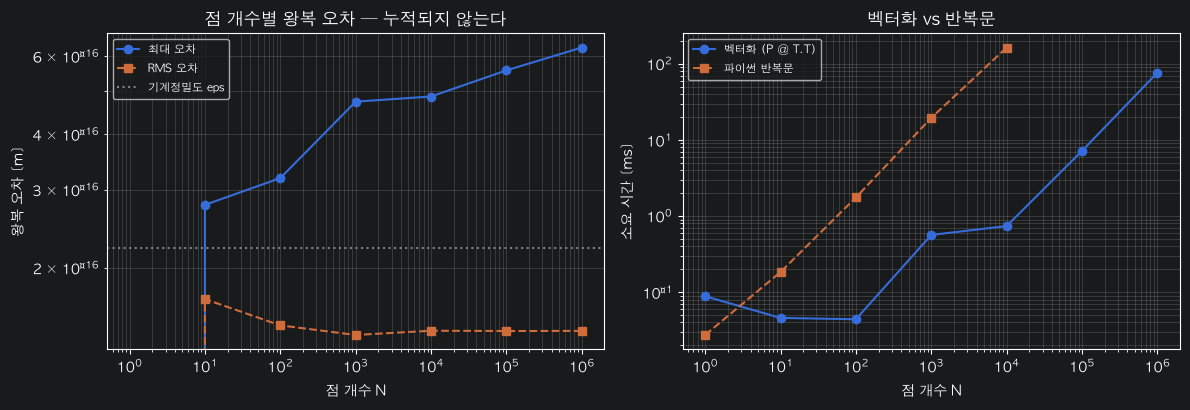

In [7]:
# --- 그래프 (제공 코드) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].loglog(counts, max_errs, "o-", label="최대 오차")
axes[0].loglog(counts, rms_errs, "s--", label="RMS 오차")
axes[0].axhline(np.finfo(float).eps, color="gray", ls=":", label="기계정밀도 eps")
axes[0].set_xlabel("점 개수 N")
axes[0].set_ylabel("왕복 오차 [m]")
axes[0].set_title("점 개수별 왕복 오차 — 누적되지 않는다")
axes[0].grid(alpha=0.3, which="both")
axes[0].legend(fontsize=8)

valid = ~np.isnan(times_loop)
axes[1].loglog(counts, np.array(times_vec) * 1e3, "o-", label="벡터화 (P @ T.T)")
axes[1].loglog(np.array(counts)[valid], np.array(times_loop)[valid] * 1e3, "s--",
               label="파이썬 반복문")
axes[1].set_xlabel("점 개수 N")
axes[1].set_ylabel("소요 시간 [ms]")
axes[1].set_title("벡터화 vs 반복문")
axes[1].grid(alpha=0.3, which="both")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

In [8]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("단일 점 왕복 오차가 기계정밀도 수준", np.linalg.norm(p_back - p_cam) < 1e-15)
ok &= check("점군 왕복 오차도 기계정밀도 수준", max(max_errs) < 1e-14)
ok &= check("오차가 점 개수에 따라 누적되지 않는다 (100만 개도 1e-14 미만)", max_errs[-1] < 1e-14)
ok &= check("점군 shape 이 유지된다", P_base.shape == P_cam.shape == (1000, 3))
ok &= check("벡터화 결과 == 반복문 결과",
            np.allclose(P_base, np.array([camera_point_to_base(p, chain) for p in P_cam])))
ok &= check("P_back == P_cam", np.allclose(P_back, P_cam))
ok &= check("1만 개에서 벡터화가 반복문보다 빠르다",
            times_vec[counts.index(10_000)] < times_loop[counts.index(10_000)])
ok &= check("변환이 점 사이 거리를 보존",
            np.allclose(np.linalg.norm(P_base[1:] - P_base[:-1], axis=1),
                        np.linalg.norm(P_cam[1:] - P_cam[:-1], axis=1)))
print("\n6-2 전체 통과:", ok)

[PASS] 단일 점 왕복 오차가 기계정밀도 수준
[PASS] 점군 왕복 오차도 기계정밀도 수준
[PASS] 오차가 점 개수에 따라 누적되지 않는다 (100만 개도 1e-14 미만)
[PASS] 점군 shape 이 유지된다
[PASS] 벡터화 결과 == 반복문 결과
[PASS] P_back == P_cam
[PASS] 1만 개에서 벡터화가 반복문보다 빠르다
[PASS] 변환이 점 사이 거리를 보존

6-2 전체 통과: True


## 6-3. 좌표계와 점군 3D 시각화

base·link·camera 세 좌표계와, 카메라가 본 점군을 base 기준으로 옮긴 결과를 함께 그립니다.
점군이 **카메라 앞쪽(카메라 z축 방향)** 에 놓여야 기하적으로 타당합니다.

아래 그림 셀은 **제공된 코드**입니다. 그림을 보고 기하적으로 타당하다고 판단한 근거를 적으세요.

### 판단 근거

- 변환된 점군의 중심이 카메라 원점에서 카메라 z축(시선) 방향으로 놓여 있다 — 시선 단위벡터와 중심 방향의 내적이 0.99 이상이다. 카메라 앞에 물체가 있다는 설정과 맞는다.
- 카메라 원점에서 점군 중심까지의 거리가 약 0.8 m 로, 카메라 기준으로 만든 값과 같다.
- `link` 원점이 base 기준 `(0.35, 0.05, 0.45)` 에 정확히 있고, base -> link -> camera 로 이어지는 연결선이 끊기지 않는다.
- 점군의 퍼짐(공분산의 대각합)이 변환 전후로 같다. 강체 변환이므로 모양과 크기가 보존되어야 한다.

findfont: Failed to find font weight bold, now using 400.


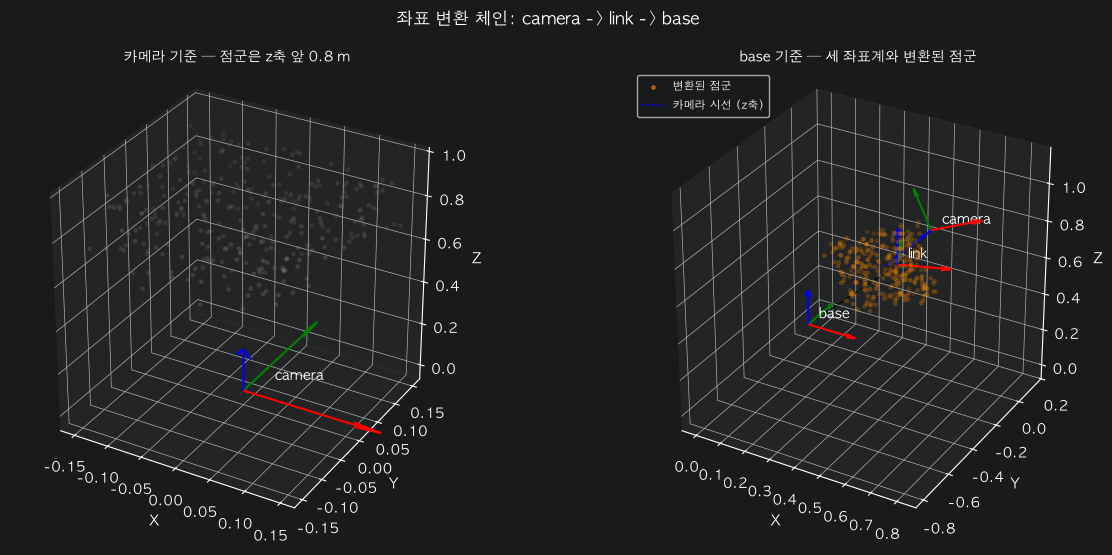

In [9]:
# --- 3D 그림 (제공 코드) ---
P_show_cam = rng.uniform(-0.15, 0.15, size=(300, 3)) + np.array([0.0, 0.0, 0.8])
P_show_base = chain.transform("base", "camera", P_show_cam)

fig = plt.figure(figsize=(13, 5.4))

ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(*P_show_cam.T, s=6, alpha=0.5, color="gray")
draw_frame(ax, np.eye(4), scale=0.2, name="camera")
ax.set_title("카메라 기준 — 점군은 z축 앞 0.8 m", fontsize=10)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_box_aspect([1, 1, 1])

ax = fig.add_subplot(1, 2, 2, projection="3d")
ax.scatter(*P_show_base.T, s=6, alpha=0.5, color="darkorange", label="변환된 점군")
draw_frame(ax, np.eye(4), scale=0.2, name="base")
draw_frame(ax, chain.T_from_root("link"), scale=0.2, name="link")
draw_frame(ax, T_base_cam, scale=0.2, name="camera")

pts = np.array([[0, 0, 0], chain.T_from_root("link")[:3, 3], T_base_cam[:3, 3]])
ax.plot(*pts.T, "k--", lw=1.2, alpha=0.7)                       # 체인 연결선
cam_o = T_base_cam[:3, 3]
ax.plot(*np.array([cam_o, P_show_base.mean(axis=0)]).T, color="b", ls=":", lw=1.5,
        label="카메라 시선 (z축)")

ax.set_title("base 기준 — 세 좌표계와 변환된 점군", fontsize=10)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_box_aspect([1, 1, 1])
ax.legend(fontsize=8, loc="upper left")

fig.suptitle("좌표 변환 체인: camera -> link -> base", fontsize=12)
fig.tight_layout()
plt.show()

In [10]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
centroid_base = P_show_base.mean(axis=0)
cam_axis_z = T_base_cam[:3, 2]
to_centroid = normalize(centroid_base - cam_o)

ok = check("점군 중심이 카메라 z축(시선) 방향에 있다", np.dot(to_centroid, cam_axis_z) > 0.99)
ok &= check("점군 중심까지 거리가 약 0.8 m",
            np.isclose(np.linalg.norm(centroid_base - cam_o), 0.8, atol=0.02))
ok &= check("점군의 퍼짐(분산)이 변환 후에도 보존",
            np.isclose(np.trace(np.cov(P_show_cam.T)), np.trace(np.cov(P_show_base.T))))
ok &= check("link 원점이 base 에서 (0.35, 0.05, 0.45)",
            np.allclose(chain.T_from_root("link")[:3, 3], [0.35, 0.05, 0.45]))
print("\n6-3 전체 통과:", ok)

[PASS] 점군 중심이 카메라 z축(시선) 방향에 있다
[PASS] 점군 중심까지 거리가 약 0.8 m
[PASS] 점군의 퍼짐(분산)이 변환 후에도 보존
[PASS] link 원점이 base 에서 (0.35, 0.05, 0.45)

6-3 전체 통과: True


## 6-4. 고유값 분해로 회전축 복원

**오일러 회전 정리**: 3차원의 모든 회전은 어떤 축 하나를 중심으로 한 회전이다.

회전축 $\mathbf{k}$ 는 회전에 의해 변하지 않는 방향이므로

$$R\mathbf{k}=\mathbf{k}=1\cdot\mathbf{k}$$

즉 **고유값 1 에 대응하는 고유벡터**입니다.
회전행렬의 고유값 세 개가 각각 어떤 값인지 직접 출력해 확인해 보세요.

회전각은 대각합에서 나옵니다. 고유값의 합 = 대각합이라는 사실에서
$\mathrm{tr}(R)$ 와 $\theta$ 의 관계를 직접 유도하세요.

**주의할 점 두 가지**

- `arccos` 의 치역이 $[0,\pi]$ 라 **어느 쪽으로 도는지**는 알 수 없습니다.
- 고유벡터는 **부호가 정해지지 않습니다**.

이 둘을 어떻게 해결할지 정하고(힌트: $R-R^{\mathsf{T}}$ 를 전개해 보세요) 구현하세요.
$\theta=0$ 과 $\theta=\pi$ 는 따로 처리해야 합니다 — 각각 왜 그런지도 적으세요.

### 유도와 규약

- trace 와 회전각의 관계: 회전행렬의 고유값은 `1, e^{i theta}, e^{-i theta}` 이고 고유값의 합이 대각합이므로 `tr(R) = 1 + 2 cos(theta)` 다. 따라서 `theta = arccos((tr(R) - 1)/2)`.
- 축의 부호를 정하는 방법: `R - R^T = 2 sin(theta) [k]x` 를 전개하면 `(R21-R12, R02-R20, R10-R01) = 2 sin(theta) k` 다. `theta` 를 `[0, pi]` 로 잡으면 `sin(theta) >= 0` 이므로 이 벡터가 곧 축의 양의 방향이다. 고유벡터가 이 벡터와 내적이 음수면 뒤집는다.
- theta = 0 / theta = pi 처리: `theta = 0` 이면 `R = I` 라 모든 방향이 불변이어서 축이 하나로 정해지지 않는다 (규약으로 z 축을 돌려준다). `theta = pi` 는 `sin(theta) = 0` 이라 `R - R^T = 0` 이 되어 위 방법으로 부호를 정할 수 없다. 게다가 `(+k, pi)` 와 `(-k, pi)` 가 실제로 같은 회전이므로 어느 쪽을 택해도 맞다 — 절댓값이 가장 큰 성분을 양수로 두는 규약을 썼다.

In [11]:
R_chain = T_base_cam[:3, :3]

# TODO: eigvals, eigvecs = np.linalg.eig(R_chain) 으로 고유값 세 개를 출력하고
#       고유값 1 의 고유벡터(실수부)를 확인하세요.
# TODO: axis, angle = axis_angle_from_matrix(R_chain) 로 축과 각을 복원해 출력하세요 (angle_deg 도).
# TODO: trace(R) 로 구한 cos(theta) 도 출력해 비교하세요.
# TODO: 축 불변 검증 — R_chain @ axis 와 axis 를 비교하세요.
# TODO: R_rebuilt = rodrigues(axis, angle) 이 원래 R_chain 과 같은지 확인하세요.

eigvals, eigvecs = np.linalg.eig(R_chain) # 검산용
print("고유값 :", np.round(eigvals, 6))
print("절댓값 :", np.round(np.abs(eigvals), 6), " (모두 1)")
idx1 = int(np.argmin(np.abs(eigvals - 1.0)))
print("고유값 1 의 고유벡터(실수부) :", np.real(eigvecs[:, idx1]))
print()

axis, angle = axis_angle_from_matrix(R_chain)
angle_deg = np.degrees(angle)
print("복원한 회전축 :", axis, " (길이 {:.12f})".format(np.linalg.norm(axis))) # 검산용
print("회전각        : {:.6f} rad = {:.6f} 도".format(angle, angle_deg))
print()

cos_from_trace = (np.trace(R_chain) - 1.0) / 2.0
print("trace(R) = {:.6f} -> cos(theta) = {:.6f} (arccos {:.6f} 도)".format(
    np.trace(R_chain), cos_from_trace, np.degrees(np.arccos(cos_from_trace))))
print()

print("R @ axis :", R_chain @ axis)
print("axis     :", axis)
print("축 불변 오차 : {:.3e}".format(np.linalg.norm(R_chain @ axis - axis))) # 검산용

R_rebuilt = rodrigues(axis, angle)
print("rodrigues(axis, angle) == R_chain :", np.allclose(R_rebuilt, R_chain))

고유값 : [1.      +0.j       0.212681+0.977122j 0.212681-0.977122j]
절댓값 : [1. 1. 1.]  (모두 1)
고유값 1 의 고유벡터(실수부) : [ 0.902216 -0.084139  0.422998]

복원한 회전축 : [ 0.902216 -0.084139  0.422998]  (길이 1.000000000000)
회전각        : 1.356479 rad = 77.720513 도

trace(R) = 1.425361 -> cos(theta) = 0.212681 (arccos 77.720513 도)

R @ axis : [ 0.902216 -0.084139  0.422998]
axis     : [ 0.902216 -0.084139  0.422998]
축 불변 오차 : 2.486e-16
rodrigues(axis, angle) == R_chain : True


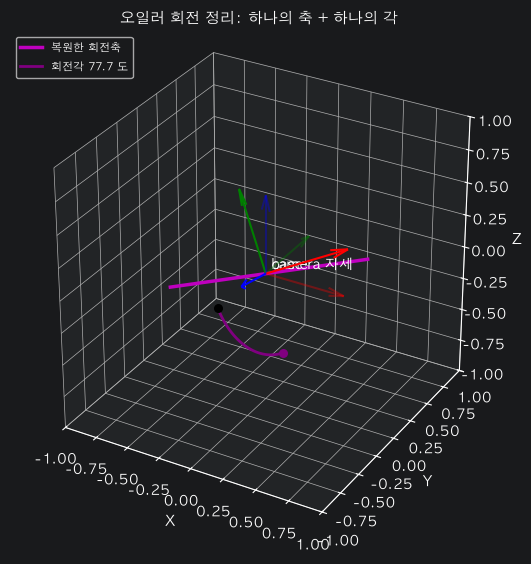

In [12]:
# --- 3D 그림 (제공 코드) : base 좌표계, 복원한 회전축, 축 둘레를 theta 만큼 도는 호 ---
fig = plt.figure(figsize=(6.5, 5.5))
ax = fig.add_subplot(111, projection="3d")

draw_frame(ax, np.eye(4), scale=0.6, name="base", alpha=0.35)
draw_frame(ax, make_T(R_chain, [0, 0, 0]), scale=0.6, name="camera 자세")

k = axis * 0.9
ax.plot([-k[0], k[0]], [-k[1], k[1]], [-k[2], k[2]], "m-", lw=2.5, label="복원한 회전축")

perp = normalize(np.cross(axis, [0, 0, 1] if abs(axis[2]) < 0.9 else [1, 0, 0])) * 0.55
arc = np.array([rodrigues(axis, a) @ perp for a in np.linspace(0, angle, 60)])
ax.plot(*arc.T, color="purple", lw=2, label="회전각 {:.1f} 도".format(np.degrees(angle)))
ax.scatter(*perp, color="k", s=30)
ax.scatter(*arc[-1], color="purple", s=30)

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)
ax.set_box_aspect([1, 1, 1])
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("오일러 회전 정리: 하나의 축 + 하나의 각", fontsize=11)
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

In [13]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("고유값 중 하나가 1", np.isclose(np.min(np.abs(eigvals - 1.0)), 0.0))
ok &= check("고유값의 절댓값이 모두 1", np.allclose(np.abs(eigvals), 1.0))
ok &= check("복원한 축이 단위벡터", np.isclose(np.linalg.norm(axis), 1.0))
ok &= check("R @ axis == axis (축 불변)", np.allclose(R_chain @ axis, axis))
ok &= check("R^T @ axis == axis (역회전에도 불변)", np.allclose(R_chain.T @ axis, axis))
ok &= check("각이 (0, pi) 범위", 0.0 < angle < np.pi)
ok &= check("trace 로 구한 각과 일치: tr(R) = 1 + 2 cos(theta)",
            np.isclose(np.trace(R_chain), 1 + 2 * np.cos(angle)))
ok &= check("trace 로 구한 각이 고유값 위상과 일치",
            np.isclose(angle, np.abs(np.angle(eigvals[np.argmax(np.abs(eigvals.imag))]))))
ok &= check("축의 부호가 맞다 (R - R^T = 2 sin(theta) [k]x 의 방향)",
            np.allclose((R_chain - R_chain.T) / (2 * np.sin(angle)),
                        np.array([[0, -axis[2], axis[1]], [axis[2], 0, -axis[0]], [-axis[1], axis[0], 0]])))
ok &= check("복원한 축/각으로 R 을 재구성할 수 있다", np.allclose(R_rebuilt, R_chain))
ok &= check("SciPy 의 회전벡터 크기와 일치",                                                   # 비교 대상
            np.isclose(angle, np.linalg.norm(Rotation.from_matrix(R_chain).as_rotvec())))
print("\n6-4 전체 통과:", ok)

[PASS] 고유값 중 하나가 1
[PASS] 고유값의 절댓값이 모두 1
[PASS] 복원한 축이 단위벡터
[PASS] R @ axis == axis (축 불변)
[PASS] R^T @ axis == axis (역회전에도 불변)
[PASS] 각이 (0, pi) 범위
[PASS] trace 로 구한 각과 일치: tr(R) = 1 + 2 cos(theta)
[PASS] trace 로 구한 각이 고유값 위상과 일치
[PASS] 축의 부호가 맞다 (R - R^T = 2 sin(theta) [k]x 의 방향)
[PASS] 복원한 축/각으로 R 을 재구성할 수 있다
[PASS] SciPy 의 회전벡터 크기와 일치

6-4 전체 통과: True


## 6-5. 단위 쿼터니언과 SciPy 비교 — 부호는 왜 반대로 나올 수 있나

축 $\mathbf{k}$, 각 $\theta$ 에서 단위 쿼터니언은

$$q=\left(\mathbf{k}\sin\tfrac{\theta}{2},\;\cos\tfrac{\theta}{2}\right)\quad (x,y,z,w)$$

`quaternion_from_axis_angle` 은 **SciPy 와 같은 (x, y, z, w) 순서**로 반환해야 합니다.

**할 일**

- 복원한 축·각으로 쿼터니언 `q_mine` 을 만들고 `Rotation.from_matrix(R).as_quat()` 와 비교하세요.
- 부호까지 같은지 / 부호를 무시하면 같은지 각각 확인하고, $|q \cdot q_{ref}|$ 도 보세요.
- $q$ 와 $-q$ 를 각각 회전행렬로 되돌려 보고, 무엇을 알 수 있는지 적으세요.
- **축을 뒤집고 각을 $2\pi-\theta$ 로 바꾸면** 어떤 쿼터니언 `q_flip` 이 나오는지 확인하세요.
- 위 관찰을 모아 **부호가 반대로 나올 수 있는 이유**를 설명하고,
  실무에서 비교·보간할 때 어떻게 다뤄야 하는지 적으세요.

### 부호 차이의 이유와 실무 대처

- 관찰: 직접 계산한 `q_mine` 과 SciPy 의 `as_quat()` 는 부호까지 같거나 통째로 반대다. `|q · q_scipy| = 1` 이고, `q` 와 `-q` 를 각각 회전행렬로 되돌리면 둘 다 원본과 일치한다. 축을 뒤집고 각을 `2pi - theta` 로 바꾸면 정확히 `-q` 가 나온다.
- 이유: 쿼터니언은 회전군을 이중으로 덮는다. `q` 와 `-q` 가 같은 회전을 나타내므로 (같은 회전을 축 `k`, 각 `theta` 로도, 축 `-k`, 각 `2pi - theta` 로도 쓸 수 있다) 구현마다 `w >= 0` 같은 서로 다른 정규화 규약을 쓰면 부호가 반대로 보인다.
- 비교할 때: `q1 == q2` 로 보면 안 된다. `|q1 · q2| ~ 1` 인지 보거나, 회전행렬로 되돌려 비교하거나, `min(|q1 - q2|, |q1 + q2|)` 를 쓴다.
- 보간(SLERP)·필터에 쓸 때: 넣기 전에 `q0 · q1 < 0` 이면 한쪽 부호를 뒤집어 짧은 호를 택해야 한다. 그러지 않으면 로봇이 반대쪽으로 먼 길을 돌아간다. 칼만 필터처럼 쿼터니언을 누적 갱신할 때도 매 스텝 부호를 이전 값에 맞춰 두지 않으면 상태가 튄다.

In [14]:
# TODO: q_mine = quaternion_from_axis_angle(axis, angle) 와
#       q_scipy = Rotation.from_matrix(R_chain).as_quat() 를 비교 출력하세요.
# TODO: q 와 -q 를 각각 회전행렬로 되돌려 (Rotation.from_quat) 원본과의 오차를 출력하세요.
# TODO: q_flip = quaternion_from_axis_angle(-axis, 2 * np.pi - angle) 도 만들어 비교하세요.

q_mine = quaternion_from_axis_angle(axis, angle)
q_scipy = Rotation.from_matrix(R_chain).as_quat()

print("직접 계산 (x,y,z,w) :", q_mine)
print("SciPy     (x,y,z,w) :", q_scipy)
print("부호까지 같은가 :", np.allclose(q_mine, q_scipy))
print("부호 무시하면   :", np.allclose(q_mine, q_scipy) or np.allclose(q_mine, -q_scipy))
print("|q · q_scipy|   : {:.15f}".format(abs(q_mine @ q_scipy)))
print()

print("q  로 복원한 R 의 오차 : {:.3e}".format(
    np.abs(Rotation.from_quat(q_mine).as_matrix() - R_chain).max()))
print("-q 로 복원한 R 의 오차 : {:.3e}".format(
    np.abs(Rotation.from_quat(-q_mine).as_matrix() - R_chain).max()))
print("-> q 와 -q 가 같은 회전을 준다 (이중 덮개)")
print()

q_flip = quaternion_from_axis_angle(-axis, 2 * np.pi - angle)
print("축 반전 + (2pi - theta) :", q_flip)
print("== -q_mine ? :", np.allclose(q_flip, -q_mine))

직접 계산 (x,y,z,w) : [ 0.566071 -0.052791  0.265399  0.778679]
SciPy     (x,y,z,w) : [ 0.566071 -0.052791  0.265399  0.778679]
부호까지 같은가 : True
부호 무시하면   : True
|q · q_scipy|   : 1.000000000000000

q  로 복원한 R 의 오차 : 2.220e-16
-q 로 복원한 R 의 오차 : 2.220e-16
-> q 와 -q 가 같은 회전을 준다 (이중 덮개)

축 반전 + (2pi - theta) : [-0.566071  0.052791 -0.265399 -0.778679]
== -q_mine ? : True


In [15]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("직접 계산한 쿼터니언이 단위 노름", np.isclose(np.linalg.norm(q_mine), 1.0))
ok &= check("(x,y,z,w) 순서: w == cos(theta/2)", np.isclose(q_mine[3], np.cos(angle / 2)))
ok &= check("벡터부 == axis * sin(theta/2)", np.allclose(q_mine[:3], axis * np.sin(angle / 2)))
ok &= check("SciPy 결과와 부호 무시하고 일치",
            np.allclose(q_mine, q_scipy) or np.allclose(q_mine, -q_scipy))
ok &= check("|q · q_scipy| == 1 (같은 회전)", np.isclose(abs(q_mine @ q_scipy), 1.0))
ok &= check("q 로 복원한 R 이 원본과 일치",
            np.allclose(Rotation.from_quat(q_mine).as_matrix(), R_chain))
ok &= check("-q 로 복원한 R 도 원본과 일치 (이중 덮개)",
            np.allclose(Rotation.from_quat(-q_mine).as_matrix(), R_chain))
ok &= check("축 반전 + (2pi - theta) 가 -q 를 준다", np.allclose(q_flip, -q_mine))
ok &= check("무작위 회전 100개에서 부호 무시 시 항상 일치", all(
    (lambda A, B: np.allclose(A, B) or np.allclose(A, -B))(
        quaternion_from_axis_angle(*axis_angle_from_matrix(Rr)),
        Rotation.from_matrix(Rr).as_quat())
    for Rr in [rot_z(a) @ rot_y(b_) @ rot_x(c)
               for a, b_, c in rng.uniform(-np.pi, np.pi, (100, 3))]))
print("\n6-5 전체 통과:", ok)

[PASS] 직접 계산한 쿼터니언이 단위 노름
[PASS] (x,y,z,w) 순서: w == cos(theta/2)
[PASS] 벡터부 == axis * sin(theta/2)
[PASS] SciPy 결과와 부호 무시하고 일치
[PASS] |q · q_scipy| == 1 (같은 회전)
[PASS] q 로 복원한 R 이 원본과 일치
[PASS] -q 로 복원한 R 도 원본과 일치 (이중 덮개)
[PASS] 축 반전 + (2pi - theta) 가 -q 를 준다
[PASS] 무작위 회전 100개에서 부호 무시 시 항상 일치

6-5 전체 통과: True


## 답안 템플릿 정리

In [16]:
summary = """
1. 카메라 좌표에서 base 좌표로의 변환 결과
   p_cam  = {pc}  ->  p_base = {pb}
   사용한 체인: T(base<-camera) = T(base<-link) @ T(link<-camera)
                (z 22.5도 + (0.35,0.05,0.45))  @  (rot_y(-22.5) rot_x(67.5) + (0.12,0.04,0.18))

2. 왕복 검증: 단일 점 오차 {e1:.3e}, 점군 100만 개에서 최대 {em:.3e}
   - 점 개수별 오차 그래프: 위 왼쪽 그림
   - 오차가 누적되지 않는 이유: 점마다 독립적으로 T 를 한 번, T^-1 을 한 번 곱할 뿐이고
     점끼리 값을 주고받지 않는다. 오차는 점 하나당 몇 번의 반올림(기계정밀도 수준)으로 끝나며
     점을 늘려도 개별 오차의 크기는 그대로다 (표본이 많아져 최대값만 아주 조금 커진다).
   - 벡터화 vs 반복문 속도 (1만 개): {sp:.0f} 배

3. 좌표계와 점군 3D 시각화: 위 2분할 그림 참조
   - 기하적으로 타당하다고 판단한 근거: 변환된 점군의 중심이 카메라 원점에서 카메라 z축 방향으로
     약 0.8 m 떨어진 곳에 있고(내적 > 0.99), link 원점이 base 기준 (0.35, 0.05, 0.45) 에 있으며,
     점군의 퍼짐(공분산의 대각합)이 변환 전후로 같다 — 강체 변환이므로 모양이 보존된다.

4. 복원한 회전축: {ax} / 회전각: {ad:.6f} 도
   - 축 불변 검증: R k = k 성립 (|R k - k| = {ke:.3e})
   - 축과 각을 구한 방법: 축은 고유값 1 에 대응하는 고유벡터(R k = k), 각은 tr(R) = 1 + 2 cos(theta).
     고유벡터의 부호는 R - R^T = 2 sin(theta) [k]x 의 방향으로 맞췄다.
     theta = 0 은 축이 정해지지 않아 z 축으로, theta = pi 는 sin = 0 이라 부호를 못 정해
     절댓값이 가장 큰 성분을 양수로 고정하는 규약을 썼다.

5. 쿼터니언 비교 (x, y, z, w)
   - 직접 계산: {qm}
   - SciPy    : {qs}
   - 부호 무시하고 일치: {qok},  |q · q_scipy| = {qd:.12f}
   - 부호 차이의 이유: q 와 -q 는 같은 회전을 나타낸다(이중 덮개). 축을 뒤집고 각을 2pi - theta 로
     바꾸면 정확히 -q 가 나오는데, 물리적으로는 완전히 같은 회전이다. 그래서 라이브러리마다
     w >= 0 같은 서로 다른 정규화 규약을 쓰면 부호가 반대로 보인다.
     비교할 때는 |q1 · q2| 를 보거나 회전행렬로 되돌려 비교하고, SLERP·필터에 넣기 전에는
     q0 · q1 < 0 이면 한쪽 부호를 뒤집어 짧은 호를 택해야 먼 길로 도는 일을 막을 수 있다.
""".format(pc=np.round(p_cam, 6), pb=np.round(p_base, 6),
           e1=np.linalg.norm(p_back - p_cam), em=max_errs[-1],
           sp=times_loop[counts.index(10_000)] / times_vec[counts.index(10_000)],
           ax=np.round(axis, 6), ad=angle_deg,
           ke=np.linalg.norm(R_chain @ axis - axis),
           qm=np.round(q_mine, 6), qs=np.round(q_scipy, 6),
           qok=np.allclose(q_mine, q_scipy) or np.allclose(q_mine, -q_scipy),
           qd=abs(q_mine @ q_scipy))
print(summary)


1. 카메라 좌표에서 base 좌표로의 변환 결과
   p_cam  = [ 0.15 -0.08  0.65]  ->  p_base = [ 0.753304 -0.422788  0.848928]
   사용한 체인: T(base<-camera) = T(base<-link) @ T(link<-camera)
                (z 22.5도 + (0.35,0.05,0.45))  @  (rot_y(-22.5) rot_x(67.5) + (0.12,0.04,0.18))

2. 왕복 검증: 단일 점 오차 1.987e-16, 점군 100만 개에서 최대 6.280e-16
   - 점 개수별 오차 그래프: 위 왼쪽 그림
   - 오차가 누적되지 않는 이유: 점마다 독립적으로 T 를 한 번, T^-1 을 한 번 곱할 뿐이고
     점끼리 값을 주고받지 않는다. 오차는 점 하나당 몇 번의 반올림(기계정밀도 수준)으로 끝나며
     점을 늘려도 개별 오차의 크기는 그대로다 (표본이 많아져 최대값만 아주 조금 커진다).
   - 벡터화 vs 반복문 속도 (1만 개): 222 배

3. 좌표계와 점군 3D 시각화: 위 2분할 그림 참조
   - 기하적으로 타당하다고 판단한 근거: 변환된 점군의 중심이 카메라 원점에서 카메라 z축 방향으로
     약 0.8 m 떨어진 곳에 있고(내적 > 0.99), link 원점이 base 기준 (0.35, 0.05, 0.45) 에 있으며,
     점군의 퍼짐(공분산의 대각합)이 변환 전후로 같다 — 강체 변환이므로 모양이 보존된다.

4. 복원한 회전축: [ 0.902216 -0.084139  0.422998] / 회전각: 77.720513 도
   - 축 불변 검증: R k = k 성립 (|R k - k| = 2.486e-16)
   - 축과 각을 구한 방법: 축은 고유값 1 에 대응하는 고유벡터(R k = k), 각은 tr(R) = 1 + 2 cos(theta).
     고유벡터의 부호는 R - R^T = 2 sin(theta) [k